In [2]:
# Import the required libraries. Add more as needed, e.g. for feature selection.

import pandas as pd
import numpy as np
import nltk
from nltk.corpus import stopwords
import re
nltk.download('stopwords')
from nltk.tokenize import word_tokenize
nltk.download('punkt')
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
import matplotlib.pyplot as plt
from scipy.stats import mode
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif, chi2
from sklearn.model_selection import cross_val_score 
from sklearn.model_selection import StratifiedKFold 

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\VuNguyen\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\VuNguyen\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [3]:
# Take the raw dataframe and split it into rating and review (rating is 1 or -1 | review is the whole text review) 
# So: "1\tGreat movie!" became:
    # rating = "1"
    # review = "Great movie!"
def data_helper(train):
    train = train[["raw"]]
    train[["rating", "review"]] = train["raw"].str.split("\t", n=1, expand=True)
    train=train[["rating", "review"]]
    return train

In [4]:
# Read the train and test data from csv files to dataframes

train = pd.read_csv("train.txt", engine="python", header = None, sep = "#EOF", names = ["raw", ""])
train=data_helper(train) # transform the raw into 2 col of rating and review
test = pd.read_csv("test.txt", engine="python", header = None, sep = "#EOF", names = ['review',""])

In [5]:
# This function takes a review as an input and returns the cleaned review
stop_words = set(stopwords.words('english'))
stop_words.remove("not")
stop_words.remove("no")
stop_words.remove("nor")
stop_words.discard("never")
stop_words.discard("very")
stop_words.discard("too")
stop_words.discard("most")
print(stop_words)

porter_stemmer = PorterStemmer()

def CleanText(review):
    
    # convert the text to lower case and then remove unnecessary text (numbers, spaces etc.) from the reviews using regex
    # if NaN then the row is discard
    if pd.isna(review):
        return ""
    review = review.lower()
    review = re.sub(r'[^a-zA-Z ]', '',review)
    # tokenize the words
    tokens = review.split()
    # remove stop words
    filter_stop_words = [word for word in tokens if word not in stop_words]
    # Apply stemming 
    cleaned_words = [porter_stemmer.stem(word) for word in filter_stop_words]
    # Join the words to form a sentence and return it
    cleaned_review = " ".join(cleaned_words)
    
    
    return cleaned_review

{'some', "couldn't", 'in', 'ourselves', 'an', "it'll", 'm', 'myself', 'why', 'yourselves', 'same', 'am', 'itself', "mightn't", "don't", 'can', 'with', "hasn't", 'other', 'these', 'on', 'than', 'them', 'we', 'him', "he's", 'isn', 'there', 'it', "they're", 'or', 'being', 'i', 't', "i've", 'again', 'are', 'doing', 'wasn', 'of', 'ours', 'between', "shan't", "she'll", 'both', "she'd", 'was', 'weren', 'which', "won't", "you'd", 'above', 'below', 'ain', 'for', 'she', 'should', "we'll", 're', "they'll", "mustn't", 'had', "needn't", "it's", 'haven', 'your', 'didn', 'has', 'after', 'don', 'himself', "didn't", 'each', "she's", "weren't", 'during', 'whom', 'does', 'against', 'further', 'hadn', 'when', 'off', 'yours', 'own', 'theirs', 'to', 'our', 'all', 'and', 'needn', "you're", "it'd", 'its', 'been', "i'd", 'hers', 'who', 'd', 'mightn', "they'd", 'won', 'because', "he'd", 'ma', 'you', 'be', 'by', 'having', 'through', "we'd", 'that', 'll', 'do', 'have', 'at', 'her', 'a', 'herself', 'will', "isn't"

In [6]:
# Apply the CleanText function to clean the reviews
train['review_cleaned'] = train['review'].apply(CleanText)
test['review_cleaned'] = test['review'].apply(CleanText)

In [7]:
# This function takes all train and test reviews as input and convert them to vectors using CountVectorizer or TfidfVectorizer
def text_feature_selector(train, test, y_train):
    
    # Initialize the CountVectorizer or TF-IDF vectorizer
    # vectorizer = TfidfVectorizer(ngram_range=(1,2)) # Tools to convert text data into numerical vectors

    vectorizer = TfidfVectorizer(
        ngram_range=(1,2),
        max_features=8000,
        min_df=2,
        max_df=0.95,
        sublinear_tf=True,
    )
    
    # Fit and transform the cleaned reviews of train using Vectorizer
    vectorizer.fit(train)
    train2 = vectorizer.transform(train)
    # Transform the cleaned review of test using the Vectorizer
    test2 = vectorizer.transform(test)
    # After this step you will be left with train features and test features
    
    # Next step is to select best features
    
    # Initialize feature selector
    feat = SelectKBest(score_func=chi2, k = 3000)
    # Fit and transform train features using the feature selector
    y_train = y_train.astype(int)
    fit = feat.fit(train2, y_train)
    # Transform the test features using the feature selector
    train_features = fit.transform(train2)
    # finally return the transformed train and test features
    test_features = fit.transform(test2)
    # return train features, test features
    return train_features, test_features

In [8]:
# This class implements the KNN algorithm

class KNN():
    def __init__(self, k = 9, similarity_function = 'cosine'):
        
        self.k = k
        self.similarity_function = similarity_function
        # You could also try Euclidean distance. Pass the similarity function accordingly while initializing the class object
    
    # Initialize the train and target
    def fit(self, train_features, train_ratings):
        self.train_features = train_features
        self.train_ratings = train_ratings
        
    # Predict the labels for test set using the nearest neighbors in train set
    def predict(self, test):
        self.test = test

        if self.similarity_function == 'euclidean':
            self.similarity = self.euclidean_distance()
            
        else:
            self.similarity = self.cosine_similarity() # Matrix


        
        # find the most frequent label of the K nearest neighbors for each sample in the test set

        # Go row by row and get the K largest sim val and return the indices of those largest sim
        top_k_idx = np.argpartition(self.similarity, -self.k, axis=1)[:, -self.k:] # Get the top K neighbors for all sample

        # Mapping the indices to training labels to fetch the labels
        neighbor_labels = self.train_ratings[top_k_idx].astype(int)

        # Find the most frequent for each test input (Just find the most common value)
        predictions, _ = mode(neighbor_labels, axis=1) # Give back the prediction but in a 2d array
        self.most_frequent_labels = predictions.ravel() # Flatten the 2d Array into a normal array
        
        return self.most_frequent_labels

    
    # Calculate the cosine similarity (write your own function)
    # This took too long going through each cell => not realistic
    # def cosine_similarity(self):
    #     trainVectors = self.train_features
    #     testVectors = self.test
    #     num_train = trainVectors.shape[0] # shape[0] is len row
    #     num_test = testVectors.shape[0]
    #     res_sim = np.zeros((num_test, num_train))
    #     for i, tv in enumerate(testVectors):
    #         for j, trv in enumerate(trainVectors):
    #             dotp = np.dot(tv, trv)
    #             mag1 = np.linalg.norm(tv)
    #             mag2 = np.linalg.norm(trv)
    #             sim_score = dotp / (mag1 * mag2)
    #             res_sim[i,j] = sim_score
    #     return res_sim # This is a 2d matrix each box contain sim score between train vec and  tst vec

    #Avoiding memory error
    def cosine_similarity(self):
        trainVectors = self.train_features.tocsr()  # ensure CSR format
        testVectors = self.test.tocsr()
    
        # Compute norms for each vector
        mag_train = np.sqrt(trainVectors.multiply(trainVectors).sum(axis=1)).A1  # shape (n_train,)
        mag_test = np.sqrt(testVectors.multiply(testVectors).sum(axis=1)).A1     # shape (n_test,)
    
        n_test, n_train = testVectors.shape[0], trainVectors.shape[0]
        res_sim = np.zeros((n_test, n_train))  # allocate row by row
    
        for i in range(n_test):
            # Compute dot product for one row at a time
            row_i = testVectors.getrow(i)
            sims = row_i @ trainVectors.T       # sparse multiplication
            sims = sims.toarray().ravel()       # convert row to dense
            epsilon = 1e-10
            res_sim[i, :] = sims / ((mag_test[i] * mag_train) + epsilon)
    
        return res_sim


In [130]:
# Cross validation to find the best K value. You can also do this to find the best feature set.
# First shuffle the entire train data and divide it into k roughly equal sized folds 
# The training and evaluation process is repeated 'k' times, with each iteration using a different fold as the test set and the remaining k-1 folds as the training set.
# The K-nearest neighbors classifier is used to predict the labels of the test set using the remaining (k-1) folds as train.
# The cross validation function should return the best K value (here K stands for number of nearest neighbors)


# from sklearn.pipeline import Pipeline 

def CrossValidation(train):
    # Have to do this bc after vectorizer it's array not dataframe anymore
    # idx = np.random.permutation(train.shape[0])
    # shuffled_train = train[idx] # shuffle train data (reset the indices after shuffling the data)
    k_values = [221, 261, 301, 351, 401] # define a list of k values
    n_folds = 5 # define the number of folds
    X = train['review_cleaned'].values  # features
    y = train['rating'].astype(int).values  # labels
    '''
    1) Divide the data into k folds (n_folds)
    
    2) After dividing the data into k folds,for each fold call text_feature_selector() to get the features of train folds and test fold
    
    3) Initialize and fit the KNN class and with the help of predict method in the KNN class, get the labels for the test fold
    
    4) Each example in test fold has a target (rating), with the help of predicted label and target, find the accuracy for each fold
    
    5) Find the average accuracy of all k-folds
    
    Repeat the above steps for all values of k in k_values
    
    Find the value of k for which the average accuracy of all folds is high compared to other k values and return it
    Also return the average accuracy of k-folds for each value of k
    '''
    accuracies = [] # Store average for each K
    # Dividing data into k-folds - Already shuffled
    cv = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=67) # an object that know how to split the data into folds
    # For each fold call text_feature_selector()
    for k in k_values:
        fold_accu = []
        for train_idx, vali_idx in cv.split(X, y): # provide train_index and test_index in each iteration
            # X is features, y is label (key)
            X_train_fold = X[train_idx]   # features for training in this fold (Train)
            y_train_fold = y[train_idx]   # labels for training in this fold (Key of the train above)
            
            X_val_fold = X[vali_idx]       # features for validation in this fold (Psedo-test valid check only)
            y_val_fold = y[vali_idx]       # labels for validation in this fold (Key for the above)
    
            # Calling text_feature_selector() on them
            train_features, validate_features = text_feature_selector(X_train_fold, X_val_fold, y_train_fold)
    
            knn = KNN(k) # Init
            # Only use the training set train data and the key for that train data
            knn.fit(train_features, y_train_fold) # KNN learn the data for this fold to transform later
    
            # Step 4: Each example in test fold has a target (rating), with the help of predicted label and target, find the accuracy for each fold
            prediction = knn.predict(validate_features) # Get the most_frequent_labels of knn matrix given the validate data (KEY)
    
            # Compare the labels given to prediction to the actual labels(psuedo) to see the accuracy
            accuracy = np.mean(prediction == y_val_fold) # will give out and array of T/F because prediction and y_val_fold are array
    
            # Add the accuracy of the fold into the list of all accuracy to find best k
            fold_accu.append(accuracy)
        # Mean accuracy to see which fold have best accuracy overall
        avg_accu_score = np.mean(fold_accu)
        accuracies.append(avg_accu_score) # Store the accu for each k fold from k = 1-40
        print(f"running k = {k}")

    best_index = np.argmax(accuracies)
    best_k = k_values[best_index]
        
    return best_k, accuracies

In [131]:
best_k, accuracies = CrossValidation(train)

running k = 221
running k = 261
running k = 301
running k = 351
running k = 401


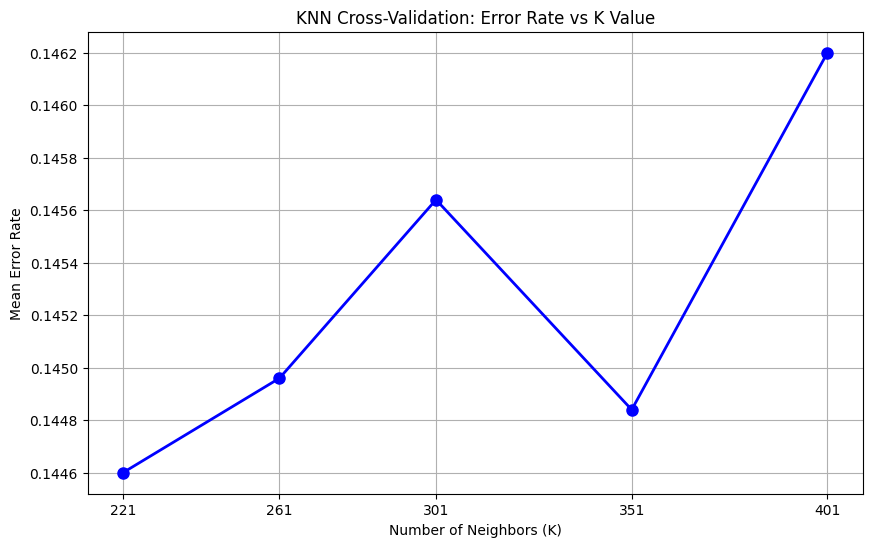

Best K: 221
K=221: Accuracy=0.8554, Error=0.1446
K=261: Accuracy=0.8550, Error=0.1450
K=301: Accuracy=0.8544, Error=0.1456
K=351: Accuracy=0.8552, Error=0.1448
K=401: Accuracy=0.8538, Error=0.1462


In [132]:
# Plot the accuracies (y-axis) vs k_values (x-axis) using matplotlib
# k_values = [1, 3, 5, 7, 9]
# # ploting the error rate to see which one is the best one
# plt.figure(figsize=(12, 6)) 
# plt.plot(k_values, accuracies, color='red', linestyle='dashed', 
# marker='o',markerfacecolor='blue', markersize=10) 
# plt.title('Error Rate K Value') 
# plt.xlabel('K Value') 
# plt.ylabel('Mean Error') 
# plt.show()
# Assuming best_k and accuracies are already computed
k_values = [221, 261, 301, 351, 401]
# Convert accuracy to error rate for clarity
error_rate = [1 - acc for acc in accuracies]

plt.figure(figsize=(10, 6))
plt.plot(k_values, error_rate, marker='o', linestyle='-', color='blue', linewidth=2, markersize=8)
plt.xticks(k_values)  # show only the k values we used
plt.title("KNN Cross-Validation: Error Rate vs K Value")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Mean Error Rate")
plt.grid(True)  # add a grid for clarity
plt.show()

print(f"Best K: {best_k}")
for k, acc, err in zip(k_values, accuracies, error_rate):
    print(f"K={k}: Accuracy={acc:.4f}, Error={err:.4f}")

In [9]:
# Initialize the KNN class with best_k value and predict the labels for test set using the entire train set
X_train_full = train['review_cleaned'].values # train
y_train_full = train['rating'].astype(int).values # key for training to lean
X_test_full = test['review_cleaned'].values # The actual test


knn = KNN(221)
train_features, test_features = text_feature_selector(X_train_full, X_test_full, y_train_full)
knn.fit(train_features, y_train_full) # KNN learn the data from training case and the key of the training case
test_prediction = knn.predict(test_features)

In [10]:
# Write the predicted labels of the test set to a .txt file and upload the .txt file to miner
with open("predictions.txt", "w") as f:
    for predict in test_prediction:
        f.write(f"{predict}\n")